In [1]:
# Run this cell to set up packages for lecture.
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

path = 'lectures/lec08'
if not Path('data').exists() or not Path('images').exists():
    !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
    !unzip -q -o /content/course.zip "cosmos-ml-cluster-2026-main/{path}/data/*" "cosmos-ml-cluster-2026-main/{path}/images/*" -d /content/course-assets
    !cp -R /content/course-assets/cosmos-ml-cluster-2026-main/{path}/data .
    !cp -R /content/course-assets/cosmos-ml-cluster-2026-main/{path}/images .

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.linewidth': 1.5,
    'grid.color': '#999999',
    'grid.alpha': 0.35,
    'font.weight': 'bold',
    'legend.fontsize': 11,
})

pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)
pd.set_option('display.precision', 3)


# Lecture 8 - Model Selection, Feature Engineering, and Cross-Validation

## COSMOS ML Cluster 2026


### Agenda

- Generalization and model complexity.
- Bias and model variance.
- Hyperparameters and cross-validation.
- Feature engineering and standardization.
- Pipelines.
- Selecting and evaluating a final classifier.


### Learning goals

By the end of today, you should be able to:

- Explain why the model with the lowest training error may not make the best future predictions.
- Describe bias and model variance using decision boundaries.
- Use cross-validation to choose a number of neighbors.
- Explain why feature scale affects k-NN.
- Combine `StandardScaler` and k-NN in a `Pipeline`.


## Opening challenge

Last time, we used 5-NN—but we did not establish that five was the best number of neighbors.

> How should we choose a classifier that will work well on points it has never seen?


## A toy classification problem

This is a simulated dataset called [moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html). Each point belongs to one of two classes. Its two features describe its horizontal and vertical position.

In [2]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('data/toy-moons.csv')
data.head()


,horizontal_position,vertical_position,class
0,1.184,0.181,purple
1,1.887,-0.383,gold
2,0.374,-0.196,gold
3,2.012,0.097,gold
4,0.418,-0.320,gold


In [3]:
features = ['horizontal_position', 'vertical_position']
class_order = ['purple', 'gold']
class_colors = {'purple': '#6f4aa8', 'gold': '#e69f00'}

X = data[features]
y = data['class']

# Use an ordinary random split. The test data stays untouched until the end.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'Training points: {len(X_train)}')
print(f'Test points kept hidden: {len(X_test)}')


Training points: 180
Test points kept hidden: 60


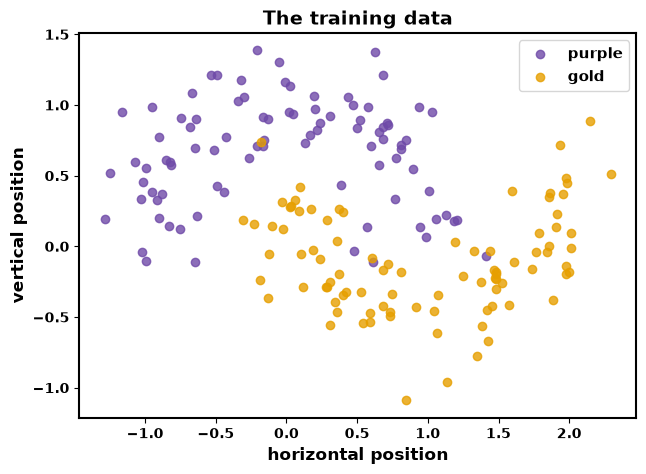

In [4]:
def scatter_classes(X_data, y_data, ax, title=None, alpha=0.8):
    for label in class_order:
        points = X_data[y_data == label]
        ax.scatter(
            points.iloc[:, 0], points.iloc[:, 1],
            s=36, alpha=alpha, color=class_colors[label], label=label
        )
    ax.set(
        xlabel=X_data.columns[0].replace('_', ' '),
        ylabel=X_data.columns[1].replace('_', ' '),
        title=title,
    )
    ax.legend()


fig, ax = plt.subplots(figsize=(8, 5))
scatter_classes(X_train, y_train, ax, 'The training data')
ax.set_aspect('equal', adjustable='box')
plt.show()


### Remember:

- k-NN finds nearby labeled training points.
- The $k$ closest points vote on the prediction.
- A decision boundary shows where predictions change.
- Training error measures mistakes on familiar points.
- We care most about predictions on new, unseen points.


## The number of neighbors controls model complexity

Before running the next cell, predict which boundary belongs to:

- 1 neighbor,
- 9 neighbors, and
- 75 neighbors.


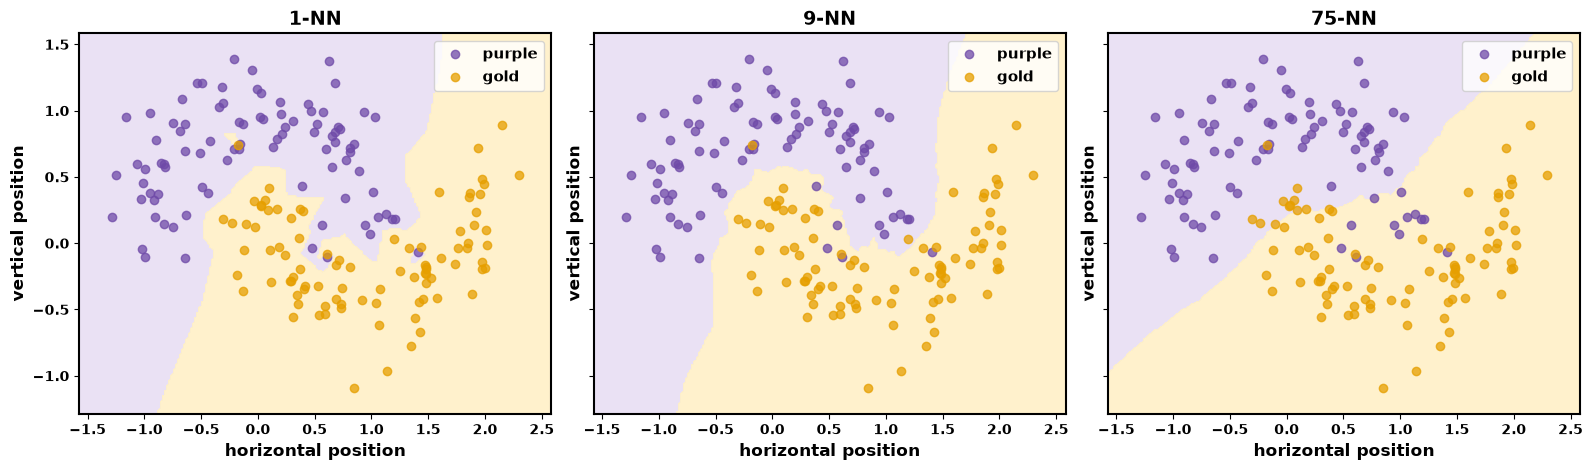

In [5]:
def plot_boundary(model, X_data, y_data, ax, title, grid_size=220):
    x_name, y_name = X_data.columns
    x_pad = 0.08 * (X_data[x_name].max() - X_data[x_name].min())
    y_pad = 0.08 * (X_data[y_name].max() - X_data[y_name].min())
    x_values = np.linspace(X_data[x_name].min() - x_pad,
                           X_data[x_name].max() + x_pad, grid_size)
    y_values = np.linspace(X_data[y_name].min() - y_pad,
                           X_data[y_name].max() + y_pad, grid_size)
    xx, yy = np.meshgrid(x_values, y_values)
    grid = pd.DataFrame({x_name: xx.ravel(), y_name: yy.ravel()})
    predicted = model.predict(grid)
    prediction_codes = pd.Categorical(
        predicted, categories=class_order
    ).codes.reshape(xx.shape)

    ax.contourf(
        xx, yy, prediction_codes,
        levels=[-0.5, 0.5, 1.5],
        colors=['#e8def3', '#fff0c7'], alpha=0.9
    )
    scatter_classes(X_data, y_data, ax, title=title, alpha=0.75)


neighbor_counts_for_picture = [1, 9, 75]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

for neighbors, ax in zip(neighbor_counts_for_picture, axes):
    model = KNeighborsClassifier(n_neighbors=neighbors).fit(X_train, y_train)
    plot_boundary(model, X_train, y_train, ax, f'{neighbors}-NN')

plt.tight_layout()
plt.show()


In [6]:
training_errors = []
for neighbors in neighbor_counts_for_picture:
    model = KNeighborsClassifier(n_neighbors=neighbors).fit(X_train, y_train)
    training_errors.append({
        'neighbors': neighbors,
        'training error': 1 - model.score(X_train, y_train),
    })

pd.DataFrame(training_errors).set_index('neighbors')


,training error
neighbors,
1,0.000
9,0.039
75,0.128


### More neighbors = smoother boundaries

| Number of neighbors | Boundary | Typical issue |
| --- | --- | --- |
| Small | Jagged and flexible | Overfitting |
| Medium | Smoother, but still local | A useful balance |
| Very large | Very smooth and "simple" | Underfitting |

**Overfitting** means learning quirks or noise in the training sample.

**Underfitting** means using a rule too simple to capture the pattern.


## Generalization

A model **generalizes** when it works well on new examples drawn from the same process as its training data.

A classifier that memorizes every training point may still generalize poorly.


## What if we collected a different training sample?

Our training data is only one possible sample. The next plot shows how the decision boundary would change if we collected new training sets. What do you notice?

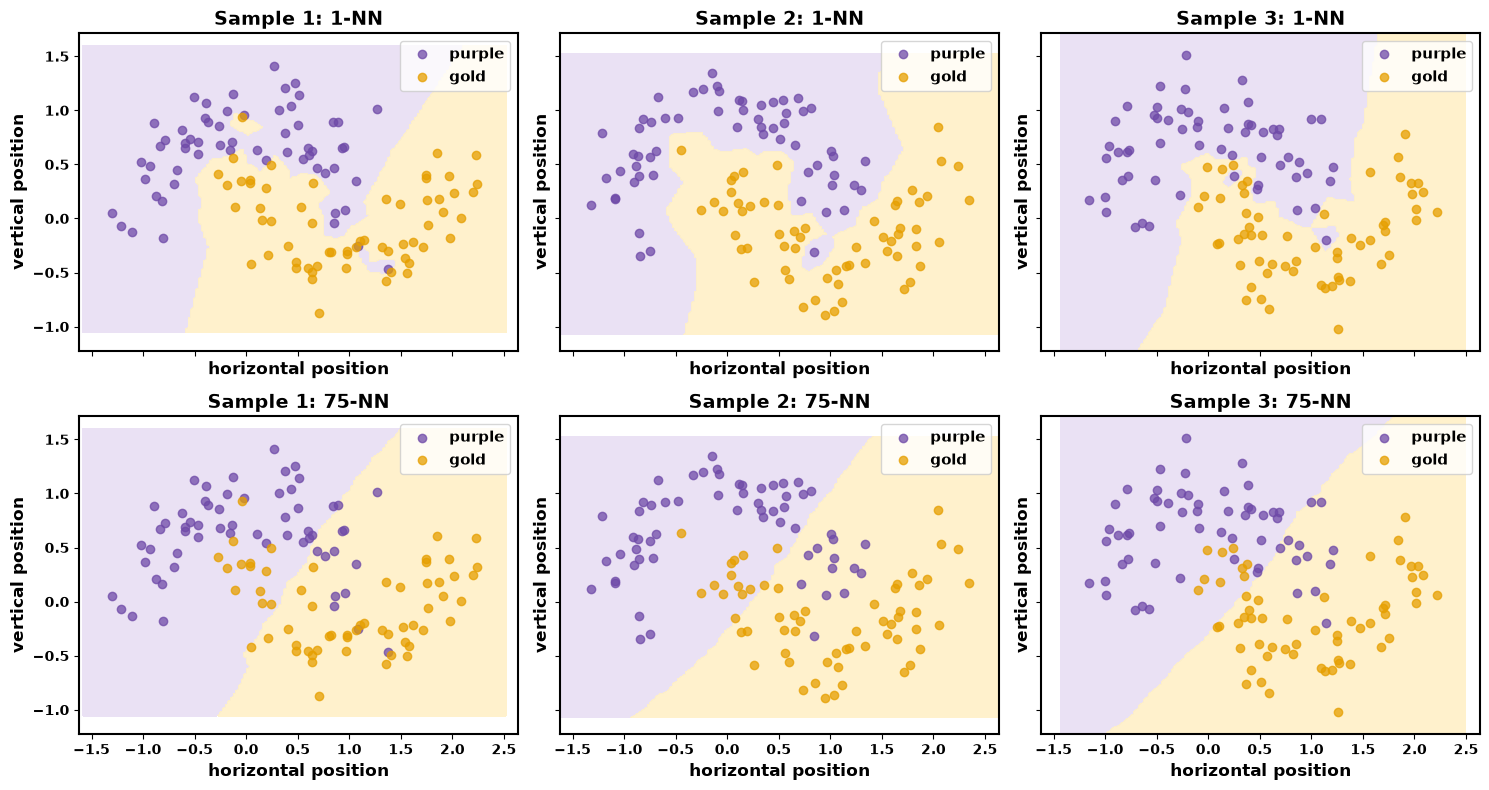

In [7]:
from sklearn.datasets import make_moons


def sample_moons(seed, n=120):
    sample_X, sample_y = make_moons(
        n_samples=n, noise=0.22, random_state=seed
    )
    sample_X = pd.DataFrame(sample_X, columns=features)
    sample_y = pd.Series(sample_y).map({0: 'purple', 1: 'gold'})
    return sample_X, sample_y


sample_seeds = [3, 11, 25]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for column, seed in enumerate(sample_seeds):
    sample_X, sample_y = sample_moons(seed)
    for row, neighbors in enumerate([1, 75]):
        model = KNeighborsClassifier(n_neighbors=neighbors).fit(sample_X, sample_y)
        plot_boundary(
            model, sample_X, sample_y, axes[row, column],
            f'Sample {column + 1}: {neighbors}-NN', grid_size=160
        )

plt.tight_layout()
plt.show()


## Bias and model variance

**Model variance** describes how much a model's predictions change when its training sample changes.

- High variance is associated with overfitting.
- 1-NN has high variance because individual points strongly control its boundary.

**Bias** describes systematic error caused by a model being unable to capture the real pattern.

- High bias is associated with underfitting.
- A very large number of neighbors smooths away useful curved structure.


### Concept Check

Suppose replacing five training points causes large sections of a classifier's decision boundary to move.

1. Does this illustrate bias or model variance?
2. Would you expect this more often with a small or large number of neighbors?


## Hyperparameters

A **hyperparameter** is a setting we choose before fitting a model.

For k-NN, the number of neighbors is a hyperparameter:

```python
KNeighborsClassifier(n_neighbors=9)
```

The training data does not automatically tell `KNeighborsClassifier` which value to use.


## Why not choose using the test set?

Suppose we try 40 neighbor counts and choose the one with the highest test accuracy.

Then our choice is tailored to that particular test set. The test set is no longer an honest simulation of future data.

So our rule going forward is: 

> Use training data to design and select the model. Use test data only ONE time, at the end.


## Idea: A single validation set

<center><img src="images/train-test-val.png" alt="Training, validation, and test split diagram" width="60%"></center>

1. Reserve separate training, validation, and test sets.
2. Fit each candidate on the training set and compare it on validation data.
3. Select the candidate with the strongest validation performance.
4. Refit using training and validation rows, then evaluate once on the test set.

**Issue:** The choice may depend too heavily on one small or unrepresentative validation set.

## A better idea: $k$-fold cross-validation

Instead of relying on a single validation set, we can create $k$ validation sets.

<center><img src="images/k-fold.png" alt="Five-fold cross-validation diagram" width="52%"></center>

Each row is used for training $k-1$ times and for validation once. The final validation score is the average of all $k$ scores and it estimates performance on unseen data.

### Concept Check

Suppose we compare a 1-NN classifier against a 5-NN classifier using 5-fold cross-validation.

1. How many classifiers are fit in total?
2. How many times is the **first row** of the training data used to fit a model?


### `KFold`

We will use the `KFold` class from scikit-learn, which makes fold sizes as equal as possible. Notice that the number of purple/gold rows can change simply because of random chance.

In [8]:
folds = KFold(n_splits=5, shuffle=True, random_state=42)

fold_summaries = []
for fold_number, (_, validation_positions) in enumerate(
    folds.split(X_train), start=1
):
    validation_labels = y_train.iloc[validation_positions]
    counts = validation_labels.value_counts()
    fold_summaries.append({
        'fold': fold_number,
        'validation rows': len(validation_positions),
        'purple': counts.get('purple', 0),
        'gold': counts.get('gold', 0),
    })

pd.DataFrame(fold_summaries).set_index('fold')


,validation rows,purple,gold
fold,,,
1,36,17,19
2,36,17,19
3,36,21,15
4,36,13,23
5,36,21,15


### Two unrelated uses of the letter $k$

Unfortunately, $k$ is used in two different places now:

- In **k-NN**, $k$ is the number of neighbors.
- In **k-fold cross-validation**, $k$ is the number of folds.

You'll have to use context clues to figure which $k$ we're referring to.

(For example, five-fold cross-validation does **not** require a 5-NN classifier.)

## How scale changes k-NN

Imagine that horizontal and vertical position are both measured in meters.

Now report horizontal position in centimeters by multiplying it by 100. We have not changed any physical locations or labels.

> Should changing units change a classifier's predictions?

(Don't worry understanding the code below completely, most of it is machinery to get the plots to look right.)

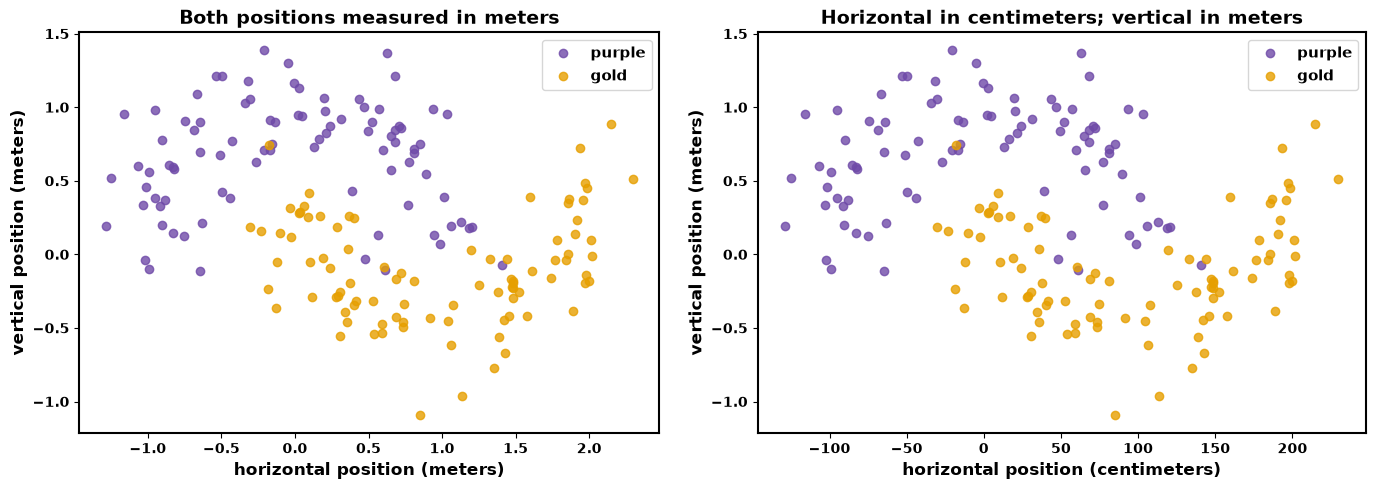

In [9]:
def use_mixed_units(X_data):
    converted = X_data.copy()
    converted['horizontal_position'] *= 100
    return converted


X_train_mixed = use_mixed_units(X_train)
X_test_mixed = use_mixed_units(X_test)  

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_classes(X_train, y_train, axes[0], 'Both positions measured in meters')
axes[0].set(xlabel='horizontal position (meters)', ylabel='vertical position (meters)')
axes[0].set_aspect('equal', adjustable='box')

scatter_classes(X_train_mixed, y_train, axes[1],
                'Horizontal in centimeters; vertical in meters')
axes[1].set(xlabel='horizontal position (centimeters)',
            ylabel='vertical position (meters)')

plt.tight_layout()
plt.show()


In [10]:
# Create unlabeled demo locations. These are not test data.
x_values = np.linspace(X_train['horizontal_position'].min(),
                       X_train['horizontal_position'].max(), 120)
y_values = np.linspace(X_train['vertical_position'].min(),
                       X_train['vertical_position'].max(), 120)
xx, yy = np.meshgrid(x_values, y_values)
demo_locations = pd.DataFrame({
    'horizontal_position': xx.ravel(),
    'vertical_position': yy.ravel(),
})
demo_locations_mixed = use_mixed_units(demo_locations)

same_units_model = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
mixed_units_model = KNeighborsClassifier(n_neighbors=5).fit(X_train_mixed, y_train)

predictions_same_units = same_units_model.predict(demo_locations)
predictions_mixed_units = mixed_units_model.predict(demo_locations_mixed)
agreement = np.mean(predictions_same_units == predictions_mixed_units)

print(f'Predictions that agree after only changing units: {agreement:.1%}')


Predictions that agree after only changing units: 73.1%


Prediction with both features in meters: gold
Prediction with mixed units: purple


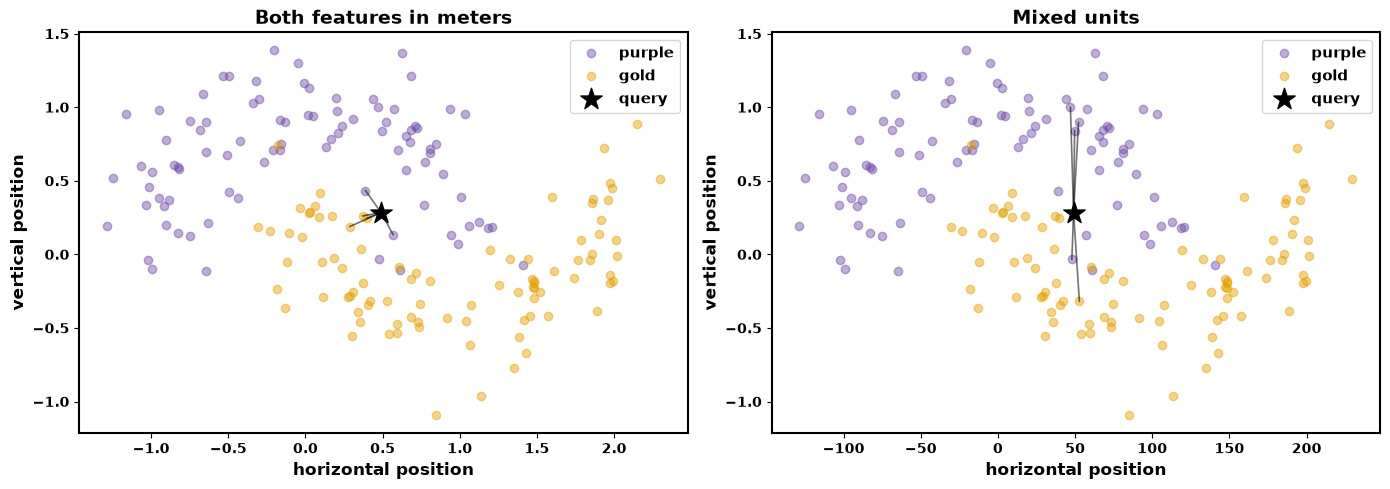

In [11]:
changed_positions = np.flatnonzero(
    predictions_same_units != predictions_mixed_units
)
changed_locations = demo_locations.iloc[changed_positions]
standardized_distance_from_center = (
    (changed_locations - X_train.mean()) / X_train.std(ddof=0)
) ** 2
most_central_disagreement = standardized_distance_from_center.sum(axis=1).argmin()
changed_position = changed_positions[most_central_disagreement]
query_meters = demo_locations.iloc[[changed_position]]
query_mixed = demo_locations_mixed.iloc[[changed_position]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train_space, query, model, title in [
    (axes[0], X_train, query_meters, same_units_model, 'Both features in meters'),
    (axes[1], X_train_mixed, query_mixed, mixed_units_model, 'Mixed units'),
]:
    scatter_classes(train_space, y_train, ax, title, alpha=0.45)
    distances, positions = model.kneighbors(query)
    neighbors = train_space.iloc[positions[0]]
    ax.scatter(query.iloc[:, 0], query.iloc[:, 1],
               marker='*', s=260, color='black', label='query')
    for _, neighbor in neighbors.iterrows():
        ax.plot(
            [query.iloc[0, 0], neighbor.iloc[0]],
            [query.iloc[0, 1], neighbor.iloc[1]],
            color='black', alpha=0.55, linewidth=1.2
        )
    ax.legend()

print('Prediction with both features in meters:',
      same_units_model.predict(query_meters)[0])
print('Prediction with mixed units:',
      mixed_units_model.predict(query_mixed)[0])
plt.tight_layout()
plt.show()


### Scaling units changes k-NN

Distance adds together differences from every feature.

When horizontal position is multiplied by 100, its contribution to distance becomes much larger. Horizontal position is effectively over-weighted, while vertical position is under-weighted. Generally speaking, this is a bad thing!

To address this, we'll introduce feature engineering.

## Feature engineering

**Feature engineering** means turning raw data into useful numerical features for a model.

Good feature engineering depends on:

- what each column means;
- the units and numerical spread of each column;
- how the model uses the features.

Scaling is especially important for models like k-NN that use distance.


## `StandardScaler`

`StandardScaler` transforms each feature into **standard units**:

$$
z = \frac{x - \text{training mean}}{\text{training standard deviation}}.
$$

After transformation, each training feature has:

- mean approximately 0;
- standard deviation approximately 1.


In [12]:
scaler = StandardScaler()
scaler.fit(X_train_mixed)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_mixed),
    columns=features,
    index=X_train_mixed.index,
)

scale_summary = pd.DataFrame({
    'mean before': X_train_mixed.mean(),
    'SD before': X_train_mixed.std(ddof=0),
    'mean after': X_train_scaled.mean(),
    'SD after': X_train_scaled.std(ddof=0),
})
scale_summary


,mean before,SD before,mean after,SD after
horizontal_position,48.011,88.188,1.184e-16,1.0
vertical_position,0.274,0.532,6.415e-17,1.0


### Be careful about your train-test split:

```python
scaler.fit(X_train) # NEVER put your original, unsplit data here!
scaler.transform(X_train) # This is fine
scaler.transform(X_test)  # This is also fine, why?
```

- `fit` learns the training means and standard deviations.
- `transform` uses those already-learned values.
- Do **not** fit the scaler on validation or test data.

Otherwise, information from supposedly unseen data leaks into the modeling process.

In [13]:
# With scaling, changing meters to centimeters no longer changes predictions.
scaled_same_units_model = make_pipeline(
    StandardScaler(), KNeighborsClassifier(n_neighbors=5)
).fit(X_train, y_train)

scaled_mixed_units_model = make_pipeline(
    StandardScaler(), KNeighborsClassifier(n_neighbors=5)
).fit(X_train_mixed, y_train)

scaled_predictions_1 = scaled_same_units_model.predict(demo_locations)
scaled_predictions_2 = scaled_mixed_units_model.predict(demo_locations_mixed)

print('Agreement without scaling:',
      f'{np.mean(predictions_same_units == predictions_mixed_units):.1%}')
print('Agreement with scaling:',
      f'{np.mean(scaled_predictions_1 == scaled_predictions_2):.1%}')


Agreement without scaling: 73.1%
Agreement with scaling: 100.0%


## Pipelines

A `Pipeline` combines feature transformations and a classifier into one object.

```python
model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=9)
)
```

This pipeline can now do all of the following with a single object:

```text
raw features → StandardScaler → k-NN → prediction
```


In [14]:
model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=9),
)

model.fit(X_train_mixed, y_train)
model.predict(demo_locations_mixed.iloc[:5])


array(['gold', 'gold', 'gold', 'gold', 'gold'], dtype=object)

### What a pipeline does

When we call `model.fit(X_train, y_train)`, the pipeline:

1. fits the scaler on `X_train`;
2. transforms `X_train`;
3. fits k-NN on the transformed values.

When we call `model.predict(X_new)`, it:

1. transforms `X_new` using the **training** means and SDs;
2. passes the transformed values to k-NN.


### Pipelines and cross-validation

And, you can pass a pipeline to cross-validation!

```python
cross_val_score(model, X_train, y_train, cv=folds)
```


## Cross-validation scores

Let's begin with three candidate neighbor counts. Each column below contains five validation accuracies—one from each fold.


In [15]:
candidate_scores = {}
for neighbors in [1, 9, 75]:
    candidate_model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=neighbors),
    )
    candidate_scores[f'{neighbors} neighbors'] = cross_val_score(
        candidate_model, X_train_mixed, y_train, cv=folds
    )

fold_scores = pd.DataFrame(
    candidate_scores,
    index=[f'Fold {i}' for i in range(1, 6)],
)
fold_scores.loc['Mean'] = fold_scores.mean()
fold_scores


,1 neighbors,9 neighbors,75 neighbors
Fold 1,0.889,0.944,0.750
Fold 2,1.000,0.944,0.917
Fold 3,0.944,0.944,0.833
Fold 4,0.944,0.972,0.833
Fold 5,0.944,0.944,0.861
Mean,0.944,0.950,0.839


## Selecting the full modeling recipe

We will compare:

- neighbor counts from 1 through 75;
- raw k-NN on the mixed-unit features;
- standardized k-NN pipelines.

In [16]:
search_results = []

for neighbors in range(1, 76, 2):
    raw_model = KNeighborsClassifier(n_neighbors=neighbors)
    scaled_model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=neighbors),
    )

    raw_validation_scores = cross_val_score(
        raw_model, X_train_mixed, y_train, cv=folds
    )
    scaled_validation_scores = cross_val_score(
        scaled_model, X_train_mixed, y_train, cv=folds
    )

    scaled_model.fit(X_train_mixed, y_train)
    search_results.append({
        'neighbors': neighbors,
        'raw validation error': 1 - raw_validation_scores.mean(),
        'scaled validation error': 1 - scaled_validation_scores.mean(),
        'validation error SD': scaled_validation_scores.std(),
        'scaled training error': 1 - scaled_model.score(X_train_mixed, y_train),
    })

search_results = pd.DataFrame(search_results)
search_results.head()


,neighbors,raw validation error,scaled validation error,validation error SD,scaled training error
0,1,0.206,0.056,0.035,0.000
1,3,0.294,0.044,0.014,0.033
2,5,0.300,0.044,0.014,0.039
3,7,0.278,0.039,0.014,0.039
4,9,0.283,0.050,0.011,0.039


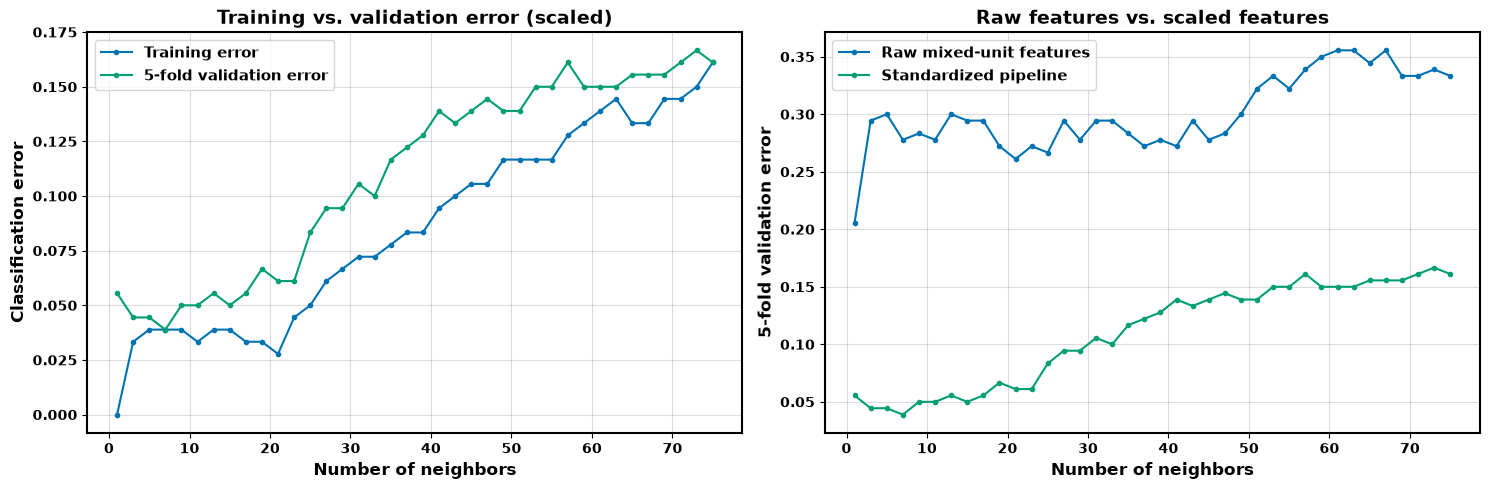

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    search_results['neighbors'], search_results['scaled training error'],
    marker='o', markersize=3, label='Training error'
)
axes[0].plot(
    search_results['neighbors'], search_results['scaled validation error'],
    marker='o', markersize=3, label='5-fold validation error'
)
axes[0].set(
    xlabel='Number of neighbors', ylabel='Classification error',
    title='Training vs. validation error (scaled)'
)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    search_results['neighbors'], search_results['raw validation error'],
    marker='o', markersize=3, label='Raw mixed-unit features'
)
axes[1].plot(
    search_results['neighbors'], search_results['scaled validation error'],
    marker='o', markersize=3, label='Standardized pipeline'
)
axes[1].set(
    xlabel='Number of neighbors', ylabel='5-fold validation error',
    title='Raw features vs. scaled features'
)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [18]:
best_row = search_results.loc[
    search_results['scaled validation error'].idxmin()
]
chosen_neighbors = int(best_row['neighbors'])

print(f'Chosen neighbor count: {chosen_neighbors}')
print(f'Mean validation error: {best_row["scaled validation error"]:.1%}')
print(f'Mean validation accuracy: {1 - best_row["scaled validation error"]:.1%}')


Chosen neighbor count: 7
Mean validation error: 3.9%
Mean validation accuracy: 96.1%


### Caveat about CV scores

Cross-validation scores depend on the particular folds and sample.

If several neighbor counts have nearly identical validation scores, there may not be a meaningful winner. A slightly simpler model can be a reasonable choice when performance is effectively tied.

## Final evaluation

We have now chosen:

- the feature transformation: standardization;
- the classifier: k-NN;
- the neighbor count: selected by cross-validation.

We can finally fit on all training rows and evaluate once on the untouched test set.


In [19]:
final_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=chosen_neighbors),
)

final_model.fit(X_train_mixed, y_train)
final_test_predictions = final_model.predict(X_test_mixed)
final_test_accuracy = final_model.score(X_test_mixed, y_test)

print(f'Final test accuracy: {final_test_accuracy:.1%}')
print(f'Final test error: {1 - final_test_accuracy:.1%}')


Final test accuracy: 96.7%
Final test error: 3.3%


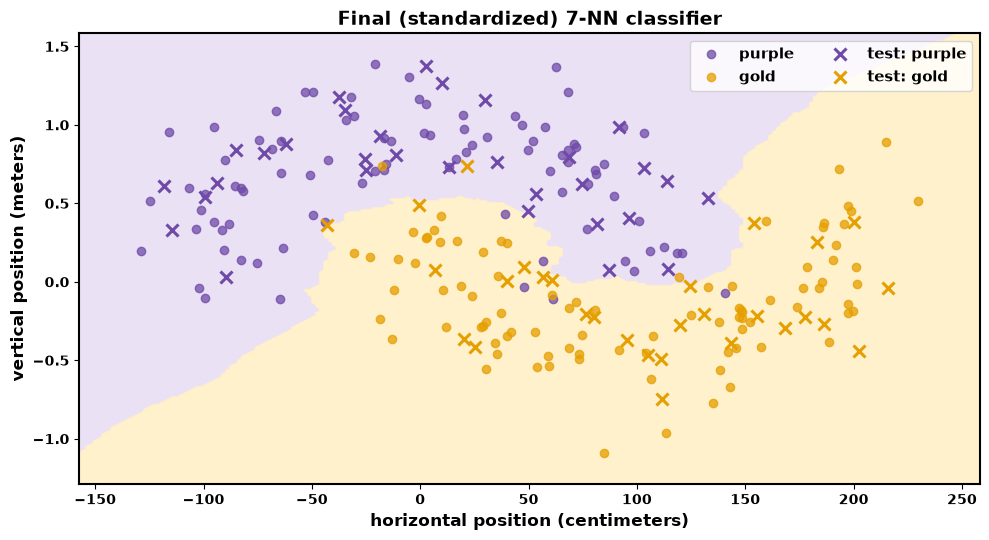

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_boundary(
    final_model, X_train_mixed, y_train, ax,
    f'Final (standardized) {chosen_neighbors}-NN classifier'
)

for label in class_order:
    points = X_test_mixed[y_test == label]
    ax.scatter(
        points.iloc[:, 0], points.iloc[:, 1],
        marker='x', s=75, linewidth=2.2,
        color=class_colors[label],
        label=f'test: {label}',
    )

ax.set(
    xlabel='horizontal position (centimeters)',
    ylabel='vertical position (meters)',
)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


## The modeling workflow

1. Split the data into training and test sets.
2. Keep the test set untouched.
3. Define candidate pipelines and hyperparameters.
4. Use cross-validation on the training data to compare candidates.
5. Choose the full modeling recipe.
6. Fit that recipe on all training data.
7. Evaluate once on the test set.


## Takeaways

- The best fit to training data is not necessarily the best predictor of new data.
- Small-neighbor k-NN is flexible and can have high model variance.
- Large-neighbor k-NN is smooth and can have high bias.
- Cross-validation helps select hyperparameters without using the test set.
- Regular `KFold` creates equally sized folds but does not balance their class proportions.
- Feature scale changes distance and therefore changes k-NN predictions.
- A pipeline keeps feature engineering and prediction together.
